In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from sklearn.metrics import roc_auc_score, average_precision_score
import seaborn as sns
import math
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, precision_recall_curve
import random

os.environ["KMP_DUPLICATE_LIB_OK"]='TRUE'

In [2]:
%matplotlib inline

# ---------------------------------------------------------------------------- #
#                              Config & Setup                                   #
# ---------------------------------------------------------------------------- #
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print("Using device:", device)

# Hyperparameters
latent_dim = 100       # latent dimension
beta = 4.0             # beta-VAE weight
epochs = 50            # training epochs
batch_size = 128
lr = 1e-3
n_mc = 50              # MC samples for dropout
lam_kl = 0.2           # KL weight in OOD score
lam_maha = 0.1         # Mahalanobis weight

torch.manual_seed(42)
np.random.seed(42)

# ---------------------------------------------------------------------------- #
#                              Data Loaders                                    #
# ---------------------------------------------------------------------------- #
transform = transforms.Compose([
    transforms.ToTensor(),  # values in [0,1]
])
train_loader = DataLoader(
    datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)
id_test_loader = DataLoader(
    datasets.FashionMNIST(root="./data", train=False, transform=transform),
    batch_size=batch_size, shuffle=False
)
ood_test_loader = DataLoader(
    datasets.MNIST(root="./data", train=False, transform=transform),
    batch_size=batch_size, shuffle=False
)

# ---------------------------------------------------------------------------- #
#                               VAE Definition                                #
# ---------------------------------------------------------------------------- #
class ConvEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
        )
        self.fc_mu     = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(128 * 7 * 7, latent_dim)

    def forward(self, x):
        h = self.net(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

class ConvDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 7 * 7)
        self.deconv = nn.Sequential(
            # 7x7 -> 14x14
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(64, 1, 4, 2, 1), nn.Sigmoid()
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 128, 7, 7)
        return self.deconv(h)

class VAE(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.encoder = ConvEncoder(latent_dim)
        self.decoder = ConvDecoder(latent_dim)

    def reparam(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparam(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

    def decode_from_mean(self, mu):
        return self.decoder(mu)

# ---------------------------------------------------------------------------- #
#                         Loss, Optimizer & Scheduler                          #
# ---------------------------------------------------------------------------- #
model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

def loss_function(recon, x, mu, logvar):
    MSE = F.mse_loss(recon, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + beta * KLD

# ---------------------------------------------------------------------------- #
#                             Training Loop                                    #
# ---------------------------------------------------------------------------- #
for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = loss_function(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    avg = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch}/{epochs} — Avg loss: {avg:.4f}")

Using device: mps
Epoch 1/50 — Avg loss: 63.9404
Epoch 2/50 — Avg loss: 47.4556
Epoch 3/50 — Avg loss: 45.3786
Epoch 4/50 — Avg loss: 43.8885
Epoch 5/50 — Avg loss: 42.8366
Epoch 6/50 — Avg loss: 42.2811
Epoch 7/50 — Avg loss: 41.8014
Epoch 8/50 — Avg loss: 41.4856
Epoch 9/50 — Avg loss: 41.2790
Epoch 10/50 — Avg loss: 41.0631
Epoch 11/50 — Avg loss: 40.8203
Epoch 12/50 — Avg loss: 40.7571
Epoch 13/50 — Avg loss: 40.6521
Epoch 14/50 — Avg loss: 40.5172
Epoch 15/50 — Avg loss: 40.4084
Epoch 16/50 — Avg loss: 40.2854
Epoch 17/50 — Avg loss: 40.1963
Epoch 18/50 — Avg loss: 40.1658
Epoch 19/50 — Avg loss: 40.0948
Epoch 20/50 — Avg loss: 39.9908
Epoch 21/50 — Avg loss: 39.9447
Epoch 22/50 — Avg loss: 39.8864
Epoch 23/50 — Avg loss: 39.8305
Epoch 24/50 — Avg loss: 39.7879
Epoch 25/50 — Avg loss: 39.6480
Epoch 26/50 — Avg loss: 39.6519
Epoch 27/50 — Avg loss: 39.5520
Epoch 28/50 — Avg loss: 39.5807
Epoch 29/50 — Avg loss: 39.5160
Epoch 30/50 — Avg loss: 39.4173
Epoch 31/50 — Avg loss: 39.4256


Combined OOD AUROC: 0.9715632700000001
Combined OOD AUPR:  0.9606617914333172


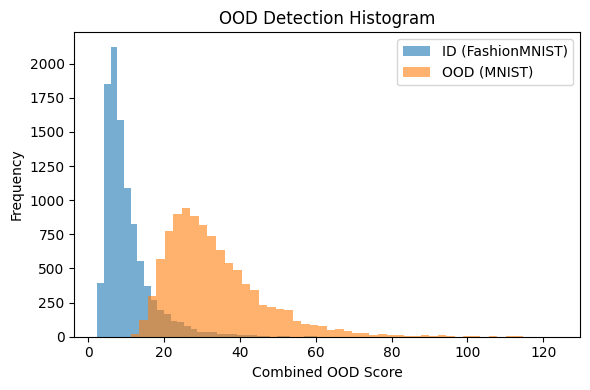

In [3]:
# ---------------------------------------------------------------------------- #
#            Compute Training Latent Means & Covariance for Mahalanobis       #
# ---------------------------------------------------------------------------- #
model.eval()
all_mu = []
with torch.no_grad():
    for x, _ in train_loader:
        mu, _ = model.encoder(x.to(device))
        all_mu.append(mu.cpu().numpy())
all_mu = np.concatenate(all_mu, axis=0)
mu_mean = all_mu.mean(axis=0)
cov = np.cov(all_mu, rowvar=False) + 1e-6 * np.eye(latent_dim)
cov_inv = np.linalg.pinv(cov)

# ---------------------------------------------------------------------------- #
#                         OOD Scoring & Metrics                                #
# ---------------------------------------------------------------------------- #
@torch.no_grad()
def compute_ood_scores(model, loader):
    model.train()
    ep_list, kl_list, maha_list = [], [], []
    for x, _ in loader:
        x = x.to(device)
        mu, logvar = model.encoder(x)
        # epistemic std via MC-dropout
        decs = torch.stack([model.decode_from_mean(mu) for _ in range(n_mc)], dim=0)
        std_map = decs.std(0)
        ep = std_map.view(x.size(0), -1).mean(1).cpu().numpy()
        # KL term
        kl = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)).cpu().numpy()
        # Mahalanobis
        delta = mu.cpu().numpy() - mu_mean
        maha = np.sum(delta @ cov_inv * delta, axis=1)
        ep_list.append(ep)
        kl_list.append(kl)
        maha_list.append(maha)
    return np.concatenate(ep_list), np.concatenate(kl_list), np.concatenate(maha_list)

# get scores for ID and OOD
id_ep,  id_kl,  id_maha  = compute_ood_scores(model, id_test_loader)
ood_ep, ood_kl, ood_maha = compute_ood_scores(model, ood_test_loader)

# combined score
t_id = id_ep + lam_kl * id_kl + lam_maha * id_maha
t_ood = ood_ep + lam_kl * ood_kl + lam_maha * ood_maha
labels = np.concatenate([np.zeros_like(t_id), np.ones_like(t_ood)])
scores = np.concatenate([t_id, t_ood])

print("\nCombined OOD AUROC:", roc_auc_score(labels, scores))
print("Combined OOD AUPR: ", average_precision_score(labels, scores))

# histogram
plt.figure(figsize=(6,4))
plt.hist(t_id,  bins=50, alpha=0.6, label="ID (FashionMNIST)")
plt.hist(t_ood, bins=50, alpha=0.6, label="OOD (MNIST)")
plt.xlabel("Combined OOD Score")
plt.ylabel("Frequency")
plt.title("OOD Detection Histogram")
plt.legend()
plt.tight_layout()
plt.show()

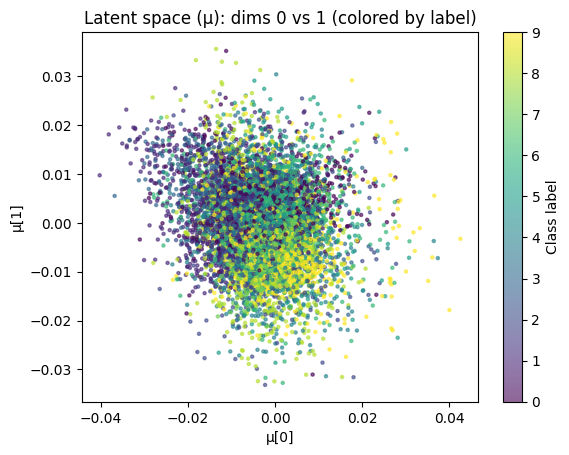

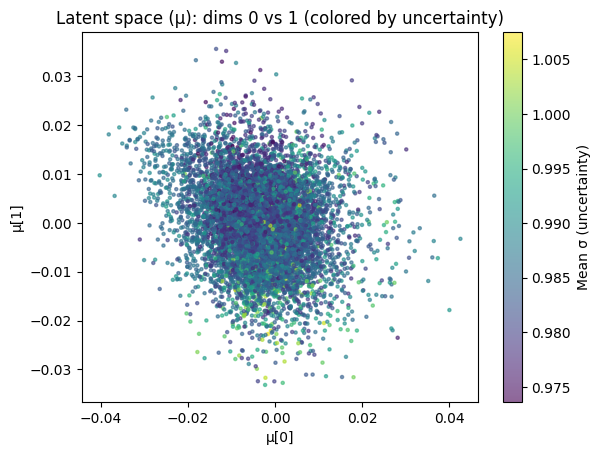

<Figure size 640x480 with 0 Axes>

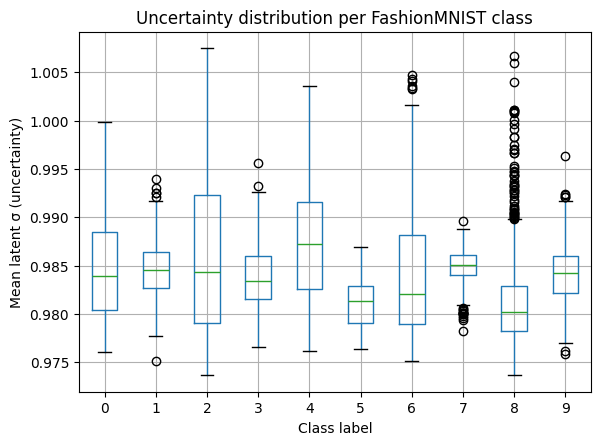

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# --- reuse your transform & loaders ---
transform = transforms.Compose([transforms.ToTensor()])
id_test_loader = DataLoader(
    datasets.FashionMNIST(root="./data", train=False, transform=transform),
    batch_size=128, shuffle=False
)

# --- assume `model` is your trained VAE in eval() mode on the same `device` ---
model.eval()

# 1) collect μ, logvar, labels
mus, logvars, labels = [], [], []
with torch.no_grad():
    for x, y in id_test_loader:
        x = x.to(device)
        mu, logvar = model.encoder(x)
        mus.append(mu.cpu().numpy())
        logvars.append(logvar.cpu().numpy())
        labels.append(y.numpy())

mus     = np.concatenate(mus,    axis=0)   # shape (N, latent_dim)
logvars = np.concatenate(logvars, axis=0)   # shape (N, latent_dim)
labels  = np.concatenate(labels,  axis=0)   # shape (N,)

# 2) compute per-sample uncertainty = mean std over latent dims
stds       = np.exp(0.5 * logvars)          # σ = exp(½ logvar)
uncertainty = stds.mean(axis=1)             # shape (N,)

# 3.1) Figure 1: latent μ[0] vs μ[1], colored by true label
plt.figure()
plt.scatter(mus[:,0], mus[:,1], c=labels, s=5, alpha=0.6)
plt.colorbar(label="Class label")
plt.title("Latent space (μ): dims 0 vs 1 (colored by label)")
plt.xlabel("μ[0]")
plt.ylabel("μ[1]")

# 3.2) Figure 2: same scatter, colored by uncertainty
plt.figure()
plt.scatter(mus[:,0], mus[:,1], c=uncertainty, s=5, alpha=0.6)
plt.colorbar(label="Mean σ (uncertainty)")
plt.title("Latent space (μ): dims 0 vs 1 (colored by uncertainty)")
plt.xlabel("μ[0]")
plt.ylabel("μ[1]")

# 3.3) Figure 3: boxplot of uncertainty per class
import pandas as pd
df = pd.DataFrame({
    "uncertainty": uncertainty,
    "label": labels.astype(str)
})
plt.figure()
df.boxplot(column="uncertainty", by="label")
plt.suptitle("")   # remove the automatic “Boxplot grouped by label” title
plt.title("Uncertainty distribution per FashionMNIST class")
plt.xlabel("Class label")
plt.ylabel("Mean latent σ (uncertainty)")

plt.show()

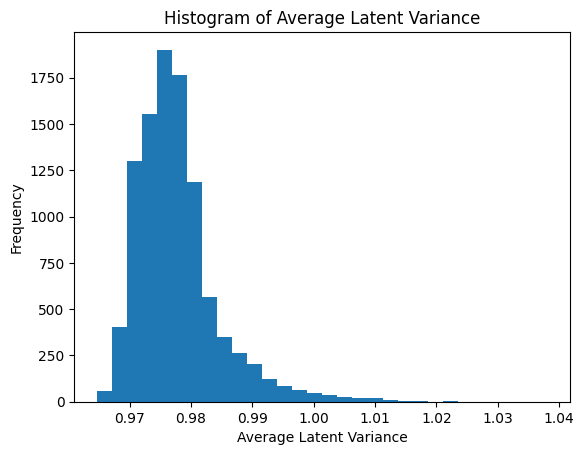

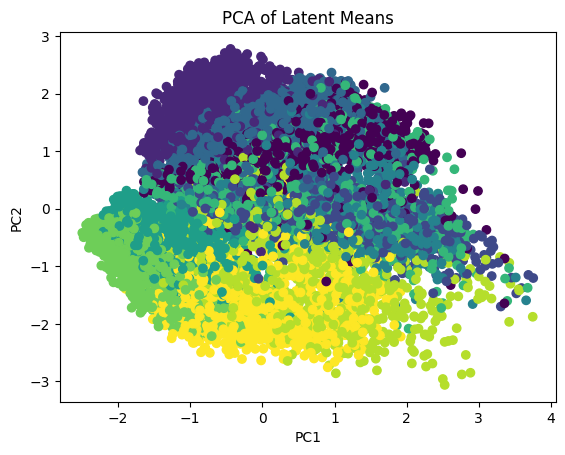

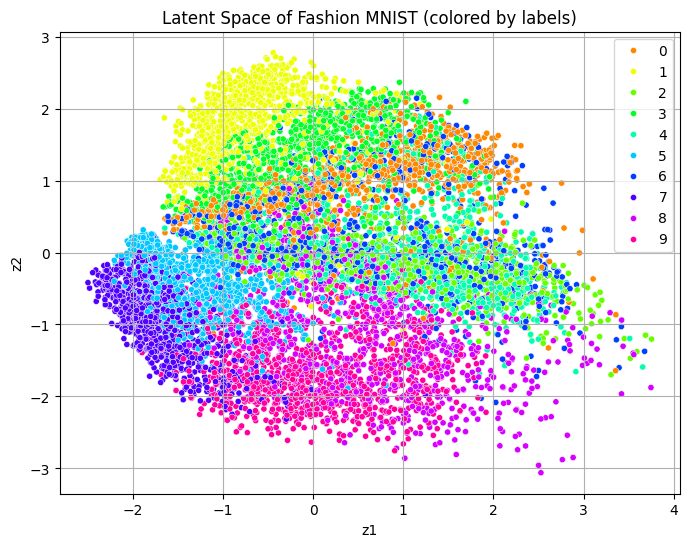

In [5]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Collect a subset of test data
model.eval()
mus = []
logvars = []
labels = []

with torch.no_grad():
    for data, target in id_test_loader:
        data = data.to(device)
        mu, logvar = model.encoder(data)
        mus.append(mu.cpu().numpy())
        logvars.append(logvar.cpu().numpy())
        labels.append(target.numpy())

mus = np.concatenate(mus, axis=0)
logvars = np.concatenate(logvars, axis=0)
labels = np.concatenate(labels, axis=0)

# Compute latent variance
var_latent = np.exp(logvars)
avg_var = var_latent.mean(axis=1)

# Plot 1: Histogram of avg latent variance
plt.figure()
plt.hist(avg_var, bins=30)
plt.title("Histogram of Average Latent Variance")
plt.xlabel("Average Latent Variance")
plt.ylabel("Frequency")

# Plot 2: PCA scatter of latent means
pca = PCA(n_components=2)
mu_2d = pca.fit_transform(mus)
plt.figure()
plt.scatter(mu_2d[:,0], mu_2d[:,1], c=labels)
plt.title("PCA of Latent Means")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.figure(figsize=(8, 6))
palette = sns.color_palette("hsv", 10)  # 10 colors for 10 labels
sns.scatterplot(x=mu_2d[:,0], y=mu_2d[:,1], hue=labels, palette=palette, legend="full", s=20)
plt.title("Latent Space of Fashion MNIST (colored by labels)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True)
plt.show()

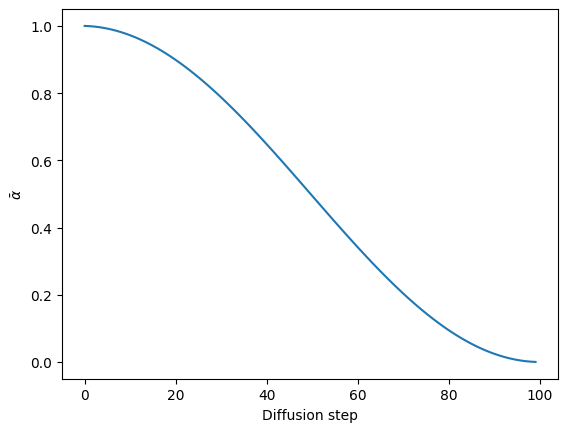

In [6]:
diffusion_steps = 100
s = 0.008
timesteps = torch.arange(0, diffusion_steps, dtype=torch.float32)
schedule = torch.cos((timesteps / diffusion_steps + s) / (1 + s) * torch.pi / 2) ** 2
baralphas = schedule / schedule[0]
betas = 1 - baralphas / torch.cat([baralphas[:1], baralphas[:-1]])
alphas = 1 - betas

sns.lineplot(baralphas)
plt.xlabel("Diffusion step")
plt.ylabel(r"$\bar{\alpha}$")
plt.show()

baralphas = baralphas.to(device)

In [7]:
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alphas_cumprod = baralphas[t].sqrt().view(-1, 1, 1, 1).to(device)
    sqrt_one_minus_alphas = (1 - baralphas[t]).sqrt().view(-1, 1, 1, 1).to(device)
    return sqrt_alphas_cumprod * x0 + sqrt_one_minus_alphas * noise, noise

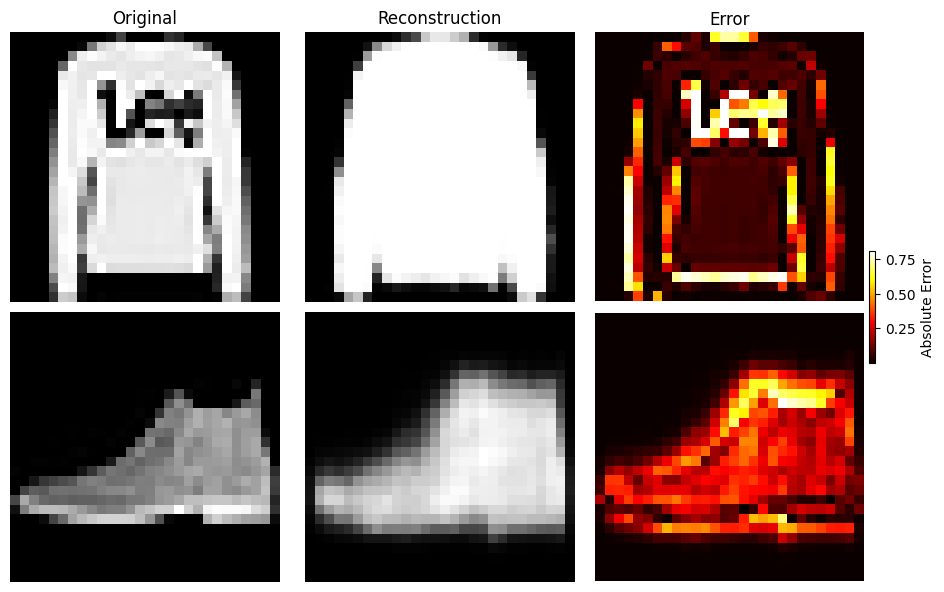

In [13]:
@torch.no_grad()
def plot_vae_recon_error(model, dataloader, n=4):
    """
    Plots an n x n grid of:
      - Original images
      - VAE reconstructions
      - Reconstruction error heatmaps (|recon - x|)
    """
    model.eval()
    x, _ = next(iter(dataloader))
    x = x.to(device)[:n*n]
    with torch.no_grad():
        recon, _, _ = model(x)
    x_np     = x.cpu().numpy()     # [B,1,H,W]
    recon_np = recon.cpu().numpy() # [B,1,H,W]
    err_np   = np.abs(recon_np - x_np)

    n = min(n, x.cpu().size(0))
    
    fig, axes = plt.subplots(n, 3, figsize=(9, n*3))
    for i in range(n*n):
        random_int = random.randint(0, n)
        row = i // n
        # original
        ax0 = axes[row, 0]
        ax0.imshow(x_np[random_int,0], cmap='gray')
        ax0.axis('off')
        if row == 0: ax0.set_title('Original')
        # recon
        ax1 = axes[row, 1]
        ax1.imshow(recon_np[random_int,0], cmap='gray')
        ax1.axis('off')
        if row == 0: ax1.set_title('Reconstruction')
        # error heatmap
        ax2 = axes[row, 2]
        im = ax2.imshow(err_np[random_int,0], cmap='hot')
        ax2.axis('off')
        if row == 0: ax2.set_title('Error')
    plt.tight_layout()
    cbar = fig.colorbar(im, ax=axes[:,2].ravel().tolist(), fraction=0.02, pad=0.02)
    cbar.set_label('Absolute Error')
    plt.show()
    fig.savefig('reconstruction.png')
    
plot_vae_recon_error(model, id_test_loader, n=2)

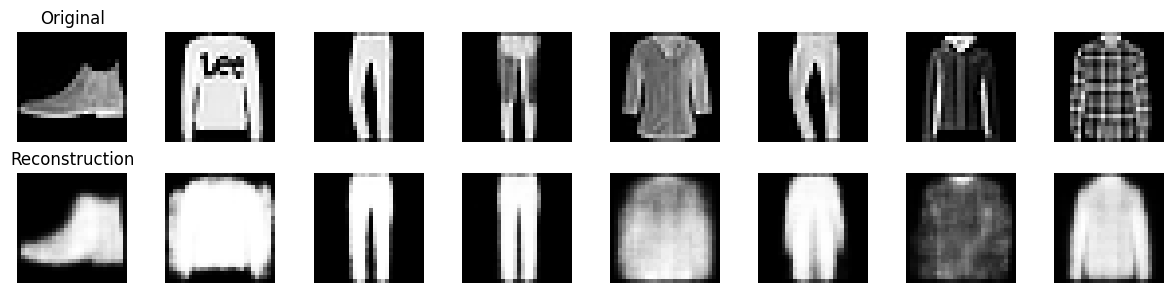

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# make sure model, device, and id_test_loader are already defined

# 1) Plot original vs. VAE reconstructions
def plot_reconstructions(model, dataloader, n=8):
    model.eval()
    # grab a batch and take the first n examples
    x, _ = next(iter(dataloader))
    x = x.to(device)[:n]
    with torch.no_grad():
        recon, _, _ = model(x)
    x_np     = x.cpu().numpy()     # [n,1,28,28]
    recon_np = recon.cpu().numpy() # [n,1,28,28]

    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i in range(n):
        axes[0,i].imshow(x_np[i,0], cmap='gray')
        axes[0,i].axis('off')
        if i==0: axes[0,i].set_title("Original")
        axes[1,i].imshow(recon_np[i,0], cmap='gray')
        axes[1,i].axis('off')
        if i==0: axes[1,i].set_title("Reconstruction")
    plt.tight_layout()
    plt.show()

# 2) Plot latent‐space posterior variances as bar charts
def plot_latent_variances(model, dataloader, n=4):
    model.eval()
    x, _ = next(iter(dataloader))
    x = x.to(device)[:n]
    with torch.no_grad():
        mu, logvar = model.encoder(x)
    var = logvar.exp().cpu().numpy()  # [n, latent_dim]

    fig, axes = plt.subplots(n, 1, figsize=(8, 2*n))
    for i in range(n):
        axes[i].bar(np.arange(var.shape[1]), var[i], width=0.8)
        axes[i].set_ylabel("Var")
        axes[i].set_xticks([])
        if i==0:
            axes[i].set_title("Latent Posterior Variance (σ²) per Dimension")
    plt.tight_layout()
    plt.show()

# Usage:
plot_reconstructions(model, id_test_loader, n=8)
# plot_latent_variances(model, id_test_loader, n=4)

In [10]:
def analyze_cvae_uncertainty(
    ep_unc: torch.Tensor, 
    img_score: torch.Tensor = None, 
    pixel_thresh: float = 0.1, 
    image_thresh: float = None
):
    """
    ep_unc: [B, 1, H, W] per‐pixel variance map
    img_score: [B] avg variance per image (optional)
    pixel_thresh: threshold for "high‐uncertainty" pixels
    image_thresh: threshold for "high‐uncertainty" images
    """
    results = {}

    # flatten all pixels across batch
    flat_pix = ep_unc.view(-1)
    results["pixel_mean"] = float(flat_pix.mean().item())
    results["pixel_std"]  = float(flat_pix.std().item())
    results["pixel_max"]  = float(flat_pix.max().item())
    results["pixel_min"]  = float(flat_pix.min().item())
    results["pixel_high_ratio"] = float((flat_pix > pixel_thresh).float().mean().item())

    if img_score is not None:
        # per‐image summary stats
        sc = img_score.detach().cpu()
        results["image_mean"] = float(sc.mean().item())
        results["image_std"]  = float(sc.std().item())
        results["image_max"]  = float(sc.max().item())
        results["image_min"]  = float(sc.min().item())
        if image_thresh is not None:
            results["image_high_ratio"] = float((sc > image_thresh).float().mean().item())

    return results

def estimate_epistemic_uncertainty(model, x, num_samples=100):
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encoder(x.to(device))
        std = torch.exp(0.5 * logvar)

        # draw all epsilons at once → (S, B, D)
        eps = torch.randn(num_samples, *std.shape, device=std.device)
        z = mu.unsqueeze(0) + eps * std.unsqueeze(0)

        # flatten to (S*B, D), decode, then un-flatten
        z_flat = z.view(-1, z.size(-1))
        recon_flat = model.decoder(z_flat)
        recon = recon_flat.view(num_samples, *x.shape)

        # per-pixel epistemic uncertainty:
        epistemic_uncertainty = recon.var(dim=0) 
        # per-image summary score:
        uncertainty_score = epistemic_uncertainty.view(x.size(0), -1).mean(dim=1)

    return epistemic_uncertainty, uncertainty_score


epi_unc, scores = estimate_epistemic_uncertainty(model, x, num_samples=50)

metrics = analyze_cvae_uncertainty(
    ep_unc     = epi_unc, 
    img_score  = scores, 
    pixel_thresh = 0.05,      # tune to your typical pixel‐variance range
    image_thresh = 0.88       # e.g. your 95th‐percentile cut
)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

pixel_mean: 0.0175
pixel_std: 0.0226
pixel_max: 0.1576
pixel_min: 0.0000
pixel_high_ratio: 0.0957
image_mean: 0.0175
image_std: 0.0055
image_max: 0.0267
image_min: 0.0068
image_high_ratio: 0.0000


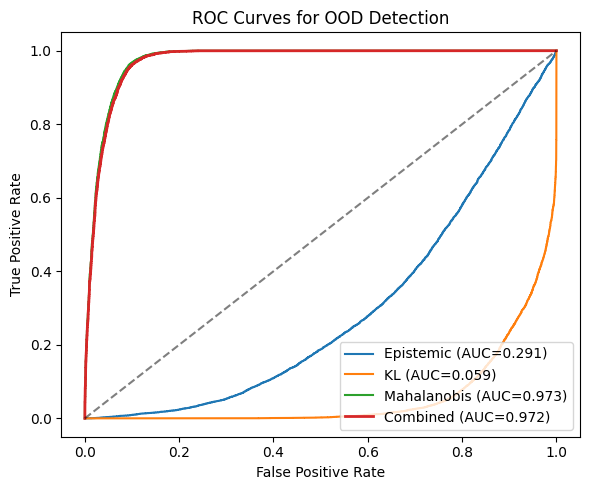

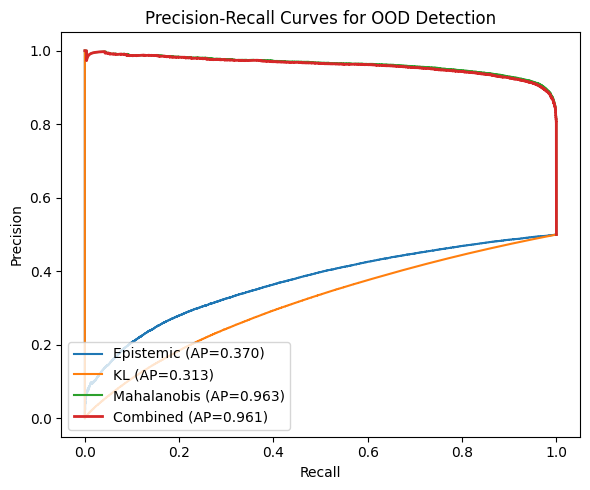

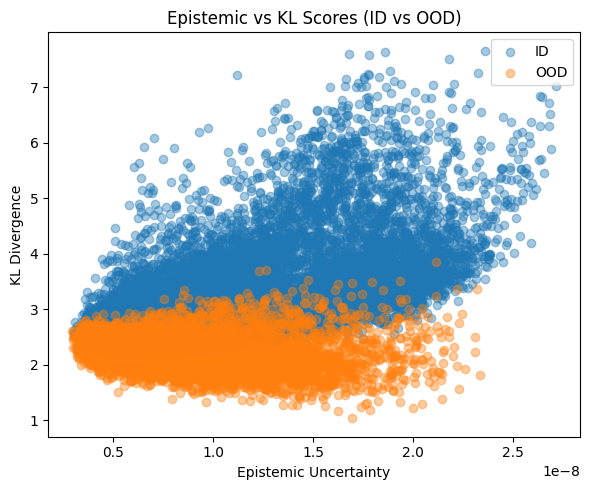

In [11]:
# Prepare labels and scores from earlier
labels = np.concatenate([np.zeros_like(id_ep), np.ones_like(ood_ep)])
ep_scores   = np.concatenate([id_ep,  ood_ep])
kl_scores   = np.concatenate([id_kl,  ood_kl])
maha_scores = np.concatenate([id_maha,ood_maha])
combined    = np.concatenate([t_id,   t_ood])

# --- 1) ROC Curves for each score ---
fpr_ep, tpr_ep, _   = roc_curve(labels, ep_scores)
fpr_kl, tpr_kl, _   = roc_curve(labels, kl_scores)
fpr_ma, tpr_ma, _   = roc_curve(labels, maha_scores)
fpr_cb, tpr_cb, _   = roc_curve(labels, combined)

plt.figure(figsize=(6,5))
plt.plot(fpr_ep,  tpr_ep,  label=f"Epistemic (AUC={roc_auc_score(labels, ep_scores):.3f})")
plt.plot(fpr_kl,  tpr_kl,  label=f"KL (AUC={roc_auc_score(labels, kl_scores):.3f})")
plt.plot(fpr_ma,  tpr_ma,  label=f"Mahalanobis (AUC={roc_auc_score(labels, maha_scores):.3f})")
plt.plot(fpr_cb,  tpr_cb,  label=f"Combined (AUC={roc_auc_score(labels, combined):.3f})", linewidth=2)
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for OOD Detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# --- 2) Precision-Recall Curves ---
prec_ep, rec_ep, _   = precision_recall_curve(labels, ep_scores)
prec_kl, rec_kl, _   = precision_recall_curve(labels, kl_scores)
prec_ma, rec_ma, _   = precision_recall_curve(labels, maha_scores)
prec_cb, rec_cb, _   = precision_recall_curve(labels, combined)

plt.figure(figsize=(6,5))
plt.plot(rec_ep, prec_ep,   label=f"Epistemic (AP={average_precision_score(labels, ep_scores):.3f})")
plt.plot(rec_kl, prec_kl,   label=f"KL (AP={average_precision_score(labels, kl_scores):.3f})")
plt.plot(rec_ma, prec_ma,   label=f"Mahalanobis (AP={average_precision_score(labels, maha_scores):.3f})")
plt.plot(rec_cb, prec_cb,   label=f"Combined (AP={average_precision_score(labels, combined):.3f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for OOD Detection")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# --- 3) Scatter Epistemic vs KL ---
plt.figure(figsize=(6,5))
plt.scatter(id_ep, id_kl,   c='C0', alpha=0.4, label='ID')
plt.scatter(ood_ep, ood_kl, c='C1', alpha=0.4, label='OOD')
plt.xlabel("Epistemic Uncertainty")
plt.ylabel("KL Divergence")
plt.title("Epistemic vs KL Scores (ID vs OOD)")
plt.legend()
plt.tight_layout()
plt.show()

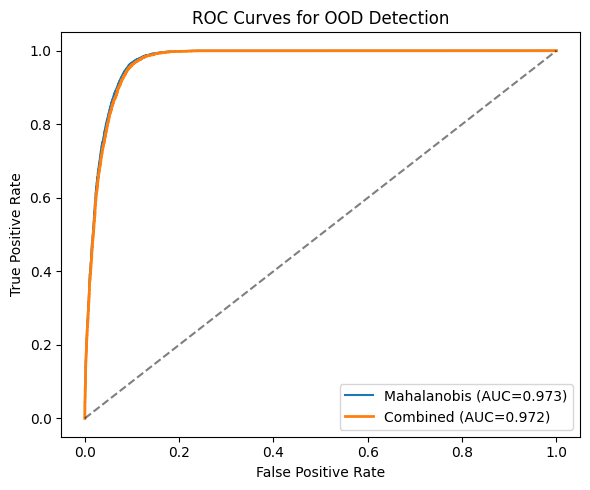

In [12]:
fpr_ma, tpr_ma, _   = roc_curve(labels, maha_scores)
fpr_cb, tpr_cb, _   = roc_curve(labels, combined)

plt.figure(figsize=(6,5))
plt.plot(fpr_ma,  tpr_ma,  label=f"Mahalanobis (AUC={roc_auc_score(labels, maha_scores):.3f})")
plt.plot(fpr_cb,  tpr_cb,  label=f"Combined (AUC={roc_auc_score(labels, combined):.3f})", linewidth=2)
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for OOD Detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()